**Prediksi Keterlambatan Pengiriman Logistik Menggunakan Machine Learning pada Data dengan Missing Value dan Outlier**

Disusun Oleh:

Nama: Muhammad Fadli.s

NIMl: F1G123025

Kelas: D

**Deskripsi Proyek:**

Penelitian ini bertujuan untuk membangun model Machine Learning dalam memprediksi keterlambatan pengiriman logistik. Dataset yang digunakan bersifat multivariat, mencakup atribut seperti asal gudang, tujuan, jasa pengiriman, berat, biaya, jarak, dan estimasi waktu pengiriman.

**Permasalahan:**

Permasalahan utama dalam penelitian ini adalah bagaimana memanfaatkan data logistik untuk memprediksi keterlambatan pengiriman secara akurat. Tantangan yang dihadapi meliputi adanya missing values, kemungkinan outlier, serta ketidakseimbangan data antara pengiriman tepat waktu dan terlambat, yang dapat mempengaruhi performa model.


**Tahap 1: Data Understanding**

Pada tahap ini dilakukan pemahaman terhadap dataset yang digunakan.

Kegiatan yang dilakukan:


*   Menjelaskan sumber dataset yang digunakan dalam penelitian.
*   Mengidentifikasi dan menjelaskan setiap fitur/variabel pada dataset.
*   Menampilkan statistik deskriptif seperti rata-rata, nilai minimum, maksimum, dan distribusi data.



Tujuan: memahami struktur dan karakteristik data sebelum diolah lebih lanjut.

In [94]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_csv('logistics_shipments_dataset (2).csv')

Saving logistics_shipments_dataset (2).csv to logistics_shipments_dataset (2) (2).csv


**Lihat Data Awal**

In [96]:
df.head()

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
0,SH10000,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2
1,SH10001,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3
2,SH10002,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2
3,SH10003,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9
4,SH10004,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3


**Melihat Informasi Data Seperti Berapa Kolom, Type Data, Jumlah Baris Data dan Sebagainya**

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2000 non-null   object 
 1   Origin_Warehouse  2000 non-null   object 
 2   Destination       2000 non-null   object 
 3   Carrier           2000 non-null   object 
 4   Shipment_Date     2000 non-null   object 
 5   Delivery_Date     1968 non-null   object 
 6   Weight_kg         2000 non-null   float64
 7   Cost              1959 non-null   float64
 8   Status            2000 non-null   object 
 9   Distance_miles    2000 non-null   int64  
 10  Transit_Days      2000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 172.0+ KB


**Melihat Statistik Data**

In [98]:
df.describe()

,Weight_kg,Cost,Distance_miles,Transit_Days
count,2000.000000,1959.000000,2000.000000,2000.000000
mean,30.184800,205.161598,1275.868000,4.182500
std,124.967053,222.586082,691.382829,1.837902
min,0.000000,17.890000,101.000000,1.000000
25%,12.300000,117.710000,690.250000,3.000000
50%,20.700000,196.420000,1262.500000,4.000000
75%,33.925000,272.115000,1867.250000,5.000000
max,5404.200000,6562.210000,2499.000000,12.000000


**Melihat Nilai Kosong Pada Data**

In [99]:
df.isnull().sum()

,0
Shipment_ID,0
Origin_Warehouse,0
Destination,0
Carrier,0
Shipment_Date,0
Delivery_Date,32
Weight_kg,0
Cost,41
Status,0
Distance_miles,0


**Melihat Outlier Pada Data**

In [100]:
num_cols = ['Weight_kg','Cost','Distance_miles','Transit_Days']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(col, ":", len(outliers))

Weight_kg : 111
Cost : 4
Distance_miles : 0
Transit_Days : 35


**TAHAP 2: DATA PREPROCESSING**

Tahap ini bertujuan untuk membersihkan dan mempersiapkan data agar siap digunakan dalam proses pemodelan.

Kegiatan yang dilakukan:


*   Mengatasi missing values (nilai kosong)
*   Menangani atau menghapus outlier jika diperlukan
*   Melakukan encoding pada data kategorikal (mengubah teks menjadi angka)
*   Melakukan normalisasi atau standarisasi data jika dibutuhkan

Tujuan: menghasilkan data yang bersih dan konsisten untuk meningkatkan performa model.

**Menangani Missing Value**

In [101]:
# Isi missing value (Cost berdasarkan warehouse & destination)
df['Cost'] = df.groupby(['Origin_Warehouse','Destination'])['Cost'].transform(lambda x: x.fillna(x.mean()))

**Menangani Outlier**

In [102]:
#Menangani Outlier dengan  IQR (Interquartile Range) menghitung batas bawah dan atas berdasarkan Q1 dan Q3. Nilai yang berada di luar batas tersebut kemudian akan disesuaikan (capping) ke nilai batas terdekat.
Q1 = df['Cost'].quantile(0.25)
Q3 = df['Cost'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Cost'] = df['Cost'].clip(lower_bound, upper_bound)

**Mengubah Tipe Data Agar Dapat Dihitung**

In [103]:
# Ubah ke datetime
df['Shipment_Date'] = pd.to_datetime(df['Shipment_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

**Feature Enginering**

In [104]:
# Feature engineering
df['Durasi'] = (df['Delivery_Date'] - df['Shipment_Date']).dt.days

**Target Klasifikasi**

In [105]:
# Target (klasifikasi)
df['Delay'] = (df['Durasi'] > df['Transit_Days']).astype(int)

Menghapus Kolom Yang Tidak Diperlukan

In [106]:
# Drop kolom tidak perlu
df = df.drop(['Shipment_ID','Shipment_Date','Delivery_Date','Status'], axis=1)

**Penggunaan encoding kategorikal di mana setiap label unik dalam suatu kolom diberi nilai integer berdasarkan urutan abjad.**

In [107]:
# Label encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Origin_Warehouse'] = le.fit_transform(df['Origin_Warehouse'])
df['Destination'] = le.fit_transform(df['Destination'])
df['Carrier'] = le.fit_transform(df['Carrier'])

In [108]:
# Cek lagi
df.isnull().sum()

,0
Origin_Warehouse,0
Destination,0
Carrier,0
Weight_kg,0
Cost,0
Distance_miles,0
Transit_Days,0
Durasi,32
Delay,0


**Tahap 3: Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan eksplorasi data untuk menemukan pola dan insight.

Kegiatan yang dilakukan:


*   Visualisasi distribusi data
*   Analisis korelasi antar variabel
*   Mengidentifikasi insight penting dari dataset

Tujuan: memahami hubungan antar variabel dan faktor yang mempengaruhi keterlambatan.

**Distribusi Target**

<Axes: title={'center': 'Distribusi Delay'}, xlabel='Delay'>

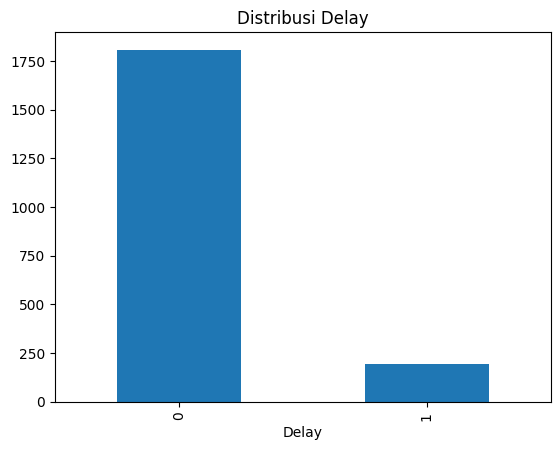

In [109]:
# Distribusi target
df['Delay'].value_counts().plot(kind='bar', title='Distribusi Delay')


**Heatmap Untuk Mengetahu Persebaran Data**

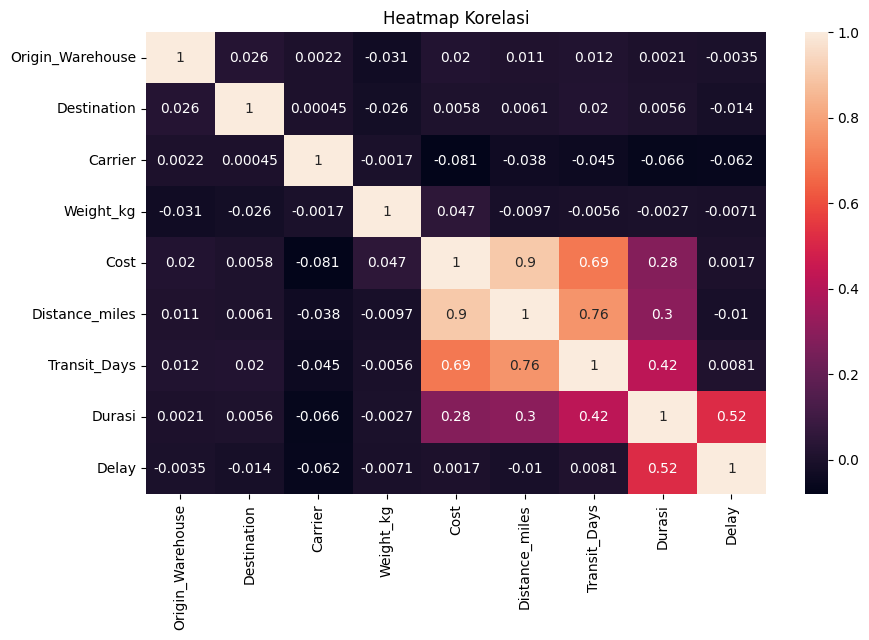

In [110]:
# Korelasi Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Heatmap Korelasi")
plt.show()

**Tahap 4: Data Splitting**

Tahap ini dilakukan untuk membagi dataset menjadi data latih (training) dan data uji (testing).

Kegiatan yang dilakukan:

Membagi data dengan minimal 3 skenario, seperti:

*   80% training : 20% testing
*   70% training : 30% testing
*   60% training : 40% testing

Tujuan: menguji performa model pada berbagai kondisi pembagian data.

**Menghapus Data Kosong Pada Kolom Durasi**

In [111]:
df = df.dropna(subset=['Durasi'])

**Data Split 3 Skenario 80:20, 70:30, 60:40**

In [112]:
from sklearn.model_selection import train_test_split

X = df.drop('Delay', axis=1)
y = df['Delay']

# 80:20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 70:30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 60:40
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

**Penggunaan SMOTE Untuk Data Imbalance**

In [113]:
# Penggunaan Smote agar data tidak imbalance
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# 80 : 20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_80_sm, y_train_80_sm = smote.fit_resample(X_train_80, y_train_80)

# 70 : 30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_train_70_sm, y_train_70_sm = smote.fit_resample(X_train_70, y_train_70)

# 60 : 40
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_train_60_sm, y_train_60_sm = smote.fit_resample(X_train_60, y_train_60)

**Tahap 5: Model Building dan Hyperparameter Tuning**

Pada tahap ini dilakukan pembangunan model menggunakan beberapa algoritma Machine Learning sekaligus melakukan hyperparameter tuning untuk meningkatkan performa model.

Kegiatan yang dilakukan:
Menggunakan minimal 3 algoritma klasifikasi, yaitu:


*   Random Forest
*   Decision Tree
*   Logistic Regression

Melakukan hyperparameter tuning pada masing-masing algoritma, seperti:


*   n_estimators, max_depth, dan min_samples_split pada Random Forest
*   max_depth dan min_samples_split pada Decision Tree
*   n_neighbors dan weights pada KNN

Tujuan: Menghasilkan model dengan performa terbaik melalui pemilihan algoritma dan kombinasi parameter yang optimal dalam memprediksi keterlambatan pengiriman.

**SKENARIO ALGORITMA 80:20**

In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# RANDOM FOREST (TUNING)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train_80_sm, y_train_80_sm)
y_pred_rf = rf.predict(X_test_80)

# DECISION TREE (TUNING)
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
dt.fit(X_train_80_sm, y_train_80_sm)
y_pred_dt = dt.predict(X_test_80)

# Logistic Regression

lr_80 = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    solver='liblinear'
)
lr_80.fit(X_train_80_sm, y_train_80_sm)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000,
                   solver='liblinear')

**SKENARIO ALGORITMA 70:30**

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# RANDOM FOREST

rf_70 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
    )
rf_70.fit(X_train_70_sm, y_train_70_sm)
y_pred_rf_70 = rf_70.predict(X_test_70)

# DECISION TREE

dt_70 = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
    )
dt_70.fit(X_train_70_sm, y_train_70_sm)
y_pred_dt_70 = dt_70.predict(X_test_70)

# Logistic Regression

lr_70 = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    solver='liblinear'
)
lr_70.fit(X_train_70_sm, y_train_70_sm)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000,
                   solver='liblinear')

**SKENARIO ALGORITMA 60:40**

In [116]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# RANDOM FOREST

rf_60 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
    )
rf_60.fit(X_train_60_sm, y_train_60_sm)
y_pred_rf_60 = rf_60.predict(X_test_60)

# DECISION TREE

dt_60 = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
    )
dt_60.fit(X_train_60_sm, y_train_60_sm)
y_pred_dt_60 = dt_60.predict(X_test_60)


lr_60 = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    solver='liblinear'
)
lr_60.fit(X_train_60_sm, y_train_60_sm)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000,
                   solver='liblinear')

**Tahap 7: Model Evaluation**

Pada tahap ini dilakukan evaluasi terhadap model yang telah dibuat.

Kegiatan yang dilakukan:

Menggunakan metrik klasifikasi seperti:


*   Accuracy
*   Precision
*   Recall
*   F1-score
*   Matrix coefisien


Tujuan: mengetahui seberapa baik model dalam melakukan prediksi.

In [117]:
# =========================
# RANDOM FOREST
# =========================
rf_80 = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)
rf_80.fit(X_train_80_sm, y_train_80_sm)

rf_70 = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)
rf_70.fit(X_train_70_sm, y_train_70_sm)

rf_60 = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)
rf_60.fit(X_train_60_sm, y_train_60_sm)


# =========================
# DECISION TREE
# =========================
dt_80 = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_80.fit(X_train_80_sm, y_train_80_sm)

dt_70 = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_70.fit(X_train_70_sm, y_train_70_sm)

dt_60 = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_60.fit(X_train_60_sm, y_train_60_sm)


# =========================
# LOGISTIC REGRESSION
# =========================
lr_80 = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    solver='liblinear'
)
lr_80.fit(X_train_80_sm, y_train_80_sm)

lr_70 = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    solver='liblinear'
)
lr_70.fit(X_train_70_sm, y_train_70_sm)

lr_60 = LogisticRegression(
    max_iter=2000,
    C=0.5,
    class_weight='balanced',
    solver='liblinear'
)
lr_60.fit(X_train_60_sm, y_train_60_sm)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=2000,
                   solver='liblinear')

=== RANDOM FOREST 80:20 ===
Accuracy: 0.9847715736040609
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       355
           1       1.00      0.85      0.92        39

    accuracy                           0.98       394
   macro avg       0.99      0.92      0.95       394
weighted avg       0.99      0.98      0.98       394



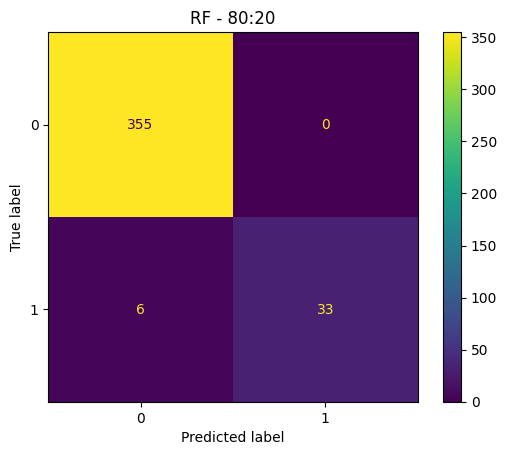


=== RANDOM FOREST 70:30 ===
Accuracy: 0.9813874788494078
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       533
           1       1.00      0.81      0.90        58

    accuracy                           0.98       591
   macro avg       0.99      0.91      0.94       591
weighted avg       0.98      0.98      0.98       591



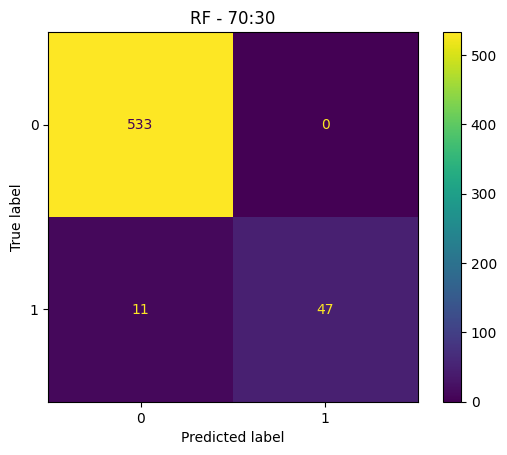


=== RANDOM FOREST 60:40 ===
Accuracy: 0.9822335025380711
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       711
           1       1.00      0.82      0.90        77

    accuracy                           0.98       788
   macro avg       0.99      0.91      0.95       788
weighted avg       0.98      0.98      0.98       788



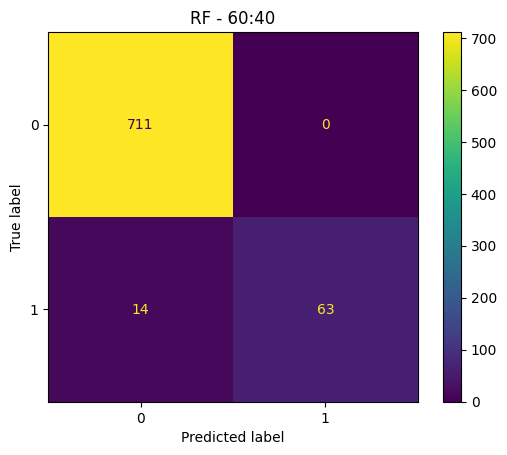


=== DECISION TREE 80:20 ===
Accuracy: 0.9974619289340102
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       355
           1       0.97      1.00      0.99        39

    accuracy                           1.00       394
   macro avg       0.99      1.00      0.99       394
weighted avg       1.00      1.00      1.00       394



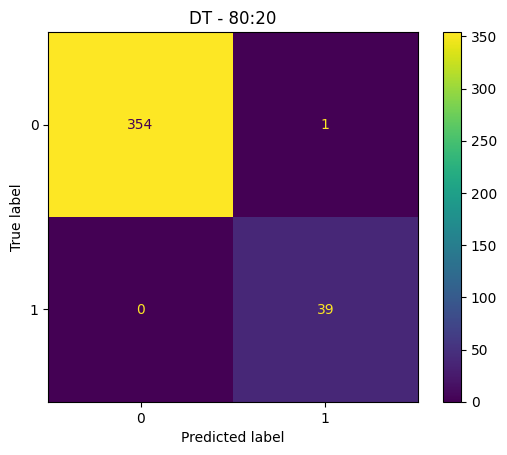


=== DECISION TREE 70:30 ===
Accuracy: 0.9949238578680203
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       533
           1       0.97      0.98      0.97        58

    accuracy                           0.99       591
   macro avg       0.98      0.99      0.99       591
weighted avg       0.99      0.99      0.99       591



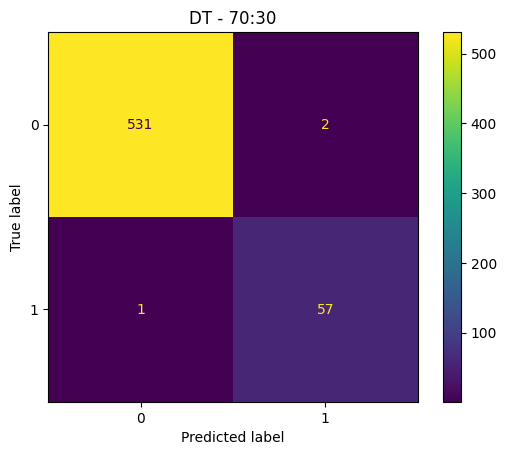


=== DECISION TREE 60:40 ===
Accuracy: 0.9936548223350253
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       711
           1       0.97      0.96      0.97        77

    accuracy                           0.99       788
   macro avg       0.98      0.98      0.98       788
weighted avg       0.99      0.99      0.99       788



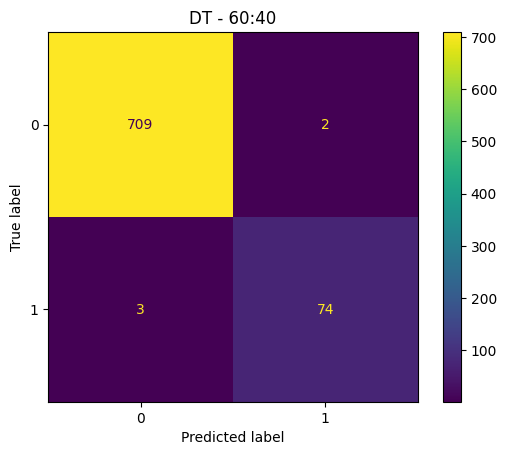


=== LOGISTIC REGRESSION 80:20 ===
Accuracy: 0.9923857868020305
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       355
           1       1.00      0.92      0.96        39

    accuracy                           0.99       394
   macro avg       1.00      0.96      0.98       394
weighted avg       0.99      0.99      0.99       394



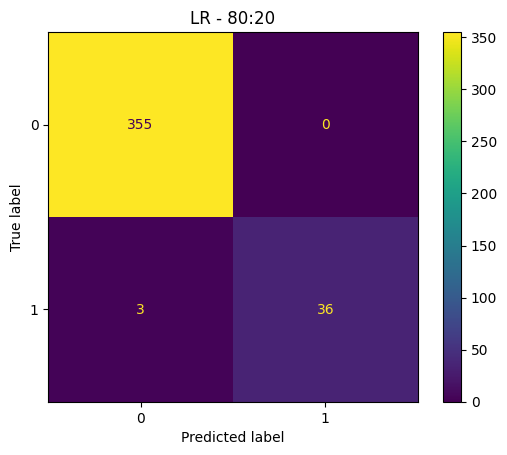


=== LOGISTIC REGRESSION 70:30 ===
Accuracy: 0.9932318104906938
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       533
           1       1.00      0.93      0.96        58

    accuracy                           0.99       591
   macro avg       1.00      0.97      0.98       591
weighted avg       0.99      0.99      0.99       591



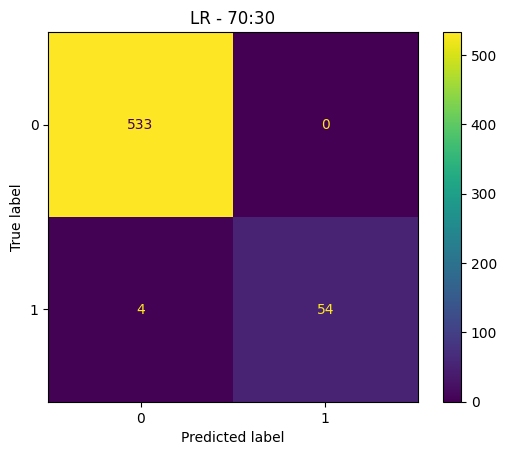


=== LOGISTIC REGRESSION 60:40 ===
Accuracy: 0.9923857868020305
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       711
           1       1.00      0.92      0.96        77

    accuracy                           0.99       788
   macro avg       1.00      0.96      0.98       788
weighted avg       0.99      0.99      0.99       788



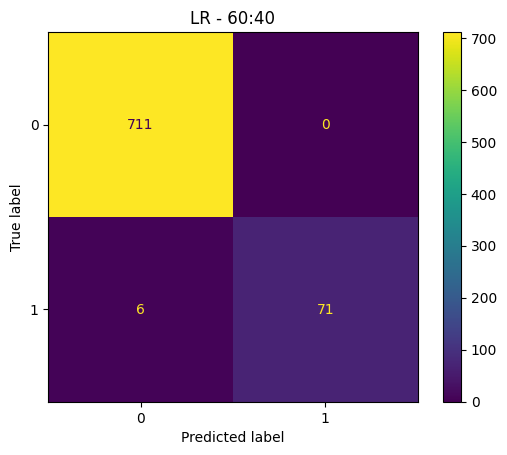

In [118]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================
# RANDOM FOREST
# =========================

# 80:20
y_pred_rf_80 = rf_80.predict(X_test_80)
print("=== RANDOM FOREST 80:20 ===")
print("Accuracy:", accuracy_score(y_test_80, y_pred_rf_80))
print(classification_report(y_test_80, y_pred_rf_80))
ConfusionMatrixDisplay(confusion_matrix(y_test_80, y_pred_rf_80)).plot()
plt.title("RF - 80:20")
plt.show()

# 70:30
y_pred_rf_70 = rf_70.predict(X_test_70)
print("\n=== RANDOM FOREST 70:30 ===")
print("Accuracy:", accuracy_score(y_test_70, y_pred_rf_70))
print(classification_report(y_test_70, y_pred_rf_70))
ConfusionMatrixDisplay(confusion_matrix(y_test_70, y_pred_rf_70)).plot()
plt.title("RF - 70:30")
plt.show()

# 60:40
y_pred_rf_60 = rf_60.predict(X_test_60)
print("\n=== RANDOM FOREST 60:40 ===")
print("Accuracy:", accuracy_score(y_test_60, y_pred_rf_60))
print(classification_report(y_test_60, y_pred_rf_60))
ConfusionMatrixDisplay(confusion_matrix(y_test_60, y_pred_rf_60)).plot()
plt.title("RF - 60:40")
plt.show()


# =========================
# DECISION TREE
# =========================

y_pred_dt_80 = dt_80.predict(X_test_80)
print("\n=== DECISION TREE 80:20 ===")
print("Accuracy:", accuracy_score(y_test_80, y_pred_dt_80))
print(classification_report(y_test_80, y_pred_dt_80))
ConfusionMatrixDisplay(confusion_matrix(y_test_80, y_pred_dt_80)).plot()
plt.title("DT - 80:20")
plt.show()

y_pred_dt_70 = dt_70.predict(X_test_70)
print("\n=== DECISION TREE 70:30 ===")
print("Accuracy:", accuracy_score(y_test_70, y_pred_dt_70))
print(classification_report(y_test_70, y_pred_dt_70))
ConfusionMatrixDisplay(confusion_matrix(y_test_70, y_pred_dt_70)).plot()
plt.title("DT - 70:30")
plt.show()

y_pred_dt_60 = dt_60.predict(X_test_60)
print("\n=== DECISION TREE 60:40 ===")
print("Accuracy:", accuracy_score(y_test_60, y_pred_dt_60))
print(classification_report(y_test_60, y_pred_dt_60))
ConfusionMatrixDisplay(confusion_matrix(y_test_60, y_pred_dt_60)).plot()
plt.title("DT - 60:40")
plt.show()


# =========================
# LOGISTIC REGRESSION
# =========================

y_pred_lr_80 = lr_80.predict(X_test_80)
print("\n=== LOGISTIC REGRESSION 80:20 ===")
print("Accuracy:", accuracy_score(y_test_80, y_pred_lr_80))
print(classification_report(y_test_80, y_pred_lr_80))
ConfusionMatrixDisplay(confusion_matrix(y_test_80, y_pred_lr_80)).plot()
plt.title("LR - 80:20")
plt.show()


y_pred_lr_70 = lr_70.predict(X_test_70)
print("\n=== LOGISTIC REGRESSION 70:30 ===")
print("Accuracy:", accuracy_score(y_test_70, y_pred_lr_70))
print(classification_report(y_test_70, y_pred_lr_70))
ConfusionMatrixDisplay(confusion_matrix(y_test_70, y_pred_lr_70)).plot()
plt.title("LR - 70:30")
plt.show()


y_pred_lr_60 = lr_60.predict(X_test_60)
print("\n=== LOGISTIC REGRESSION 60:40 ===")
print("Accuracy:", accuracy_score(y_test_60, y_pred_lr_60))
print(classification_report(y_test_60, y_pred_lr_60))
ConfusionMatrixDisplay(confusion_matrix(y_test_60, y_pred_lr_60)).plot()
plt.title("LR - 60:40")
plt.show()

**Tahap 8: Model Comparison**

Tahap akhir adalah membandingkan performa seluruh model.

Kegiatan yang dilakukan:


*   Membuat tabel atau grafik perbandingan
*   Membandingkan akurasi dan performa tiap algoritma
*   Membandingkan hasil dari setiap skenario data splitting


Tujuan: menentukan model terbaik berdasarkan hasil evaluasi.

In [119]:
#Tabel Perbandingan
import pandas as pd

hasil = pd.DataFrame({
    'Model': ['Random Forest','Decision Tree','Logistic Regression'],
    '80:20': [
        accuracy_score(y_test_80, y_pred_rf_80),
        accuracy_score(y_test_80, y_pred_dt_80),
        accuracy_score(y_test_80, y_pred_lr_80)
    ],
    '70:30': [
        accuracy_score(y_test_70, y_pred_rf_70),
        accuracy_score(y_test_70, y_pred_dt_70),
        accuracy_score(y_test_70, y_pred_lr_70)
    ],
    '60:40': [
        accuracy_score(y_test_60, y_pred_rf_60),
        accuracy_score(y_test_60, y_pred_dt_60),
        accuracy_score(y_test_60, y_pred_lr_60)
    ]
})

print(hasil)

                 Model     80:20     70:30     60:40
0        Random Forest  0.984772  0.981387  0.982234
1        Decision Tree  0.997462  0.994924  0.993655
2  Logistic Regression  0.992386  0.993232  0.992386


**Tahap 9: Inferensi Model**

Tahap ini merupakan tahap akhir setelah model terbaik diperoleh, yaitu melakukan proses inferensi atau prediksi terhadap data baru menggunakan model yang telah dilatih.

Kegiatan yang dilakukan:


*   Memilih model terbaik berdasarkan hasil evaluasi dan perbandingan
*   Menggunakan model tersebut untuk melakukan prediksi pada data baru (data yang belum pernah dilihat model)
*   Menampilkan hasil prediksi untuk mengetahui apakah suatu pengiriman mengalami keterlambatan atau tidak


Tujuan:
Mengimplementasikan model dalam bentuk sederhana untuk melihat bagaimana model bekerja dalam memprediksi keterlambatan pengiriman pada data baru tanpa perlu melakukan deployment sistem secara penuh.

In [120]:
#Data Baru Untuk Skenari0 80:20

data_baru = [[
    2,   # Origin_Warehouse (sudah encoding)
    5,   # Destination
    1,   # Carrier
    10,  # Weight_kg
    200, # Cost
    1500,# Distance_miles
    5,   # Transit_Days
    15    # Durasi
]]

# RANDOM FOREST
pred_rf = rf_80.predict(data_baru)[0]

# DECISION TREE
pred_dt = dt_80.predict(data_baru)[0]

# LOGISTIC REGRESSION
pred_lr = lr_80.predict(data_baru)[0]


# HASIL
print("=== HASIL PREDIKSI ===")

print("\nRandom Forest:")
print("Terlambat" if pred_rf == 1 else "Tidak Terlambat")

print("\nDecision Tree:")
print("Terlambat" if pred_dt == 1 else "Tidak Terlambat")

print("\nLogistic Regression:")
print("Terlambat" if pred_lr == 1 else "Tidak Terlambat")

=== HASIL PREDIKSI ===

Random Forest:
Terlambat

Decision Tree:
Terlambat

Logistic Regression:
Terlambat


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [121]:
#Data Baru Untuk Skenario 70:30
data_baru = [[
    2,   # Origin_Warehouse (sudah encoding)
    5,   # Destination
    1,   # Carrier
    8,  # Weight_kg
    300, # Cost
    1500,# Distance_miles
    5,   # Transit_Days
    1    # Durasi
]]

# RANDOM FOREST
pred_rf = rf_70.predict(data_baru)[0]

# DECISION TREE
pred_dt = dt_70.predict(data_baru)[0]

# LOGISTIC REGRESSION
pred_lr = lr_70.predict(data_baru)[0]


# HASIL
print("=== HASIL PREDIKSI ===")

print("\nRandom Forest:")
print("Terlambat" if pred_rf == 1 else "Tidak Terlambat")

print("\nDecision Tree:")
print("Terlambat" if pred_dt == 1 else "Tidak Terlambat")

print("\nLogistic Regression:")
print("Terlambat" if pred_lr == 1 else "Tidak Terlambat")

=== HASIL PREDIKSI ===

Random Forest:
Tidak Terlambat

Decision Tree:
Tidak Terlambat

Logistic Regression:
Tidak Terlambat


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [122]:
#Data Baru Untuk Skenario 60:40
data_baru = [[
    2,   # Origin_Warehouse (sudah encoding)
    5,   # Destination
    1,   # Carrier
    10,  # Weight_kg
    200, # Cost
    1500,# Distance_miles
    5,   # Transit_Days
    15    # Durasi
]]

# RANDOM FOREST
pred_rf = rf_60.predict(data_baru)[0]

# DECISION TREE
pred_dt = dt_60.predict(data_baru)[0]

# LOGISTIC REGRESSION
pred_lr = lr_60.predict(data_baru)[0]


# HASIL
print("=== HASIL PREDIKSI ===")

print("\nRandom Forest:")
print("Terlambat" if pred_rf == 1 else "Tidak Terlambat")

print("\nDecision Tree:")
print("Terlambat" if pred_dt == 1 else "Tidak Terlambat")

print("\nLogistic Regression:")
print("Terlambat" if pred_lr == 1 else "Tidak Terlambat")

=== HASIL PREDIKSI ===

Random Forest:
Terlambat

Decision Tree:
Terlambat

Logistic Regression:
Terlambat


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
